In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

df = pd.read_csv("../data/processed/pune_traffic_intelligent.csv")

print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (9736, 13)


,time,direction,car_count,bike_count,bus_count,truck_count,total_vehicles,intersection,camera,source_file,traffic_level,traffic_pressure,recommended_green
0,1900-01-01 08:55:00,DOWN,1.0,0.0,0.0,0.0,1.0,JehangirChowk,j1,j1_12.csv,LOW,1.0,15
1,1900-01-01 08:55:00,LEFT,1.0,0.0,0.0,0.0,1.0,JehangirChowk,j1,j1_12.csv,LOW,1.0,15
2,1900-01-01 08:55:00,RIGHT,0.0,0.0,0.0,0.0,0.0,JehangirChowk,j1,j1_12.csv,LOW,0.0,15
3,1900-01-01 08:55:00,UP,0.0,0.0,0.0,0.0,0.0,JehangirChowk,j1,j1_12.csv,LOW,0.0,15
4,1900-01-01 09:00:00,DOWN,77.0,122.0,3.0,10.0,212.0,JehangirChowk,j1,j1_12.csv,VERY_HIGH,175.5,60


In [2]:
FIXED_GREEN = 30
MIN_GREEN = 15
MAX_GREEN = 60

pressure_ref = df["traffic_pressure"].quantile(0.95)

df["fixed_green"] = FIXED_GREEN

def reactive_green(pressure):
    normalized = min(max(pressure / pressure_ref, 0), 1)

    green = MIN_GREEN + normalized * (MAX_GREEN - MIN_GREEN)

    return round(green)

df["reactive_green"] = df["traffic_pressure"].apply(
    reactive_green
)

display(
    df[
        [
            "intersection",
            "direction",
            "total_vehicles",
            "traffic_pressure",
            "fixed_green",
            "reactive_green"
        ]
    ].head(20)
)

,intersection,direction,total_vehicles,traffic_pressure,fixed_green,reactive_green
0,JehangirChowk,DOWN,1.0,1.0,30,15
1,JehangirChowk,LEFT,1.0,1.0,30,15
2,JehangirChowk,RIGHT,0.0,0.0,30,15
3,JehangirChowk,UP,0.0,0.0,30,15
4,JehangirChowk,DOWN,212.0,175.5,30,60
5,JehangirChowk,LEFT,59.0,58.5,30,32
6,JehangirChowk,RIGHT,57.0,72.5,30,36
7,JehangirChowk,UP,4.0,3.5,30,16
8,JehangirChowk,DOWN,246.0,205.0,30,60
9,JehangirChowk,LEFT,44.0,46.0,30,28


In [3]:
print("Reactive green-time statistics:")
display(df["reactive_green"].describe())

print("\nMost congested observations:")

display(
    df.sort_values(
        "traffic_pressure",
        ascending=False
    )[
        [
            "intersection",
            "direction",
            "total_vehicles",
            "traffic_pressure",
            "fixed_green",
            "reactive_green"
        ]
    ].head(15)
)

Reactive green-time statistics:


count    9736.000000
mean       28.399856
std        14.580145
min        15.000000
25%        16.000000
50%        22.000000
75%        37.000000
max        60.000000
Name: reactive_green, dtype: float64


Most congested observations:


,intersection,direction,total_vehicles,traffic_pressure,fixed_green,reactive_green
4355,AlankarChowk,UP,1586.0,1589.5,30,60
3743,AlankarChowk,UP,1490.0,1487.0,30,60
4367,AlankarChowk,UP,1156.0,1329.0,30,60
4331,AlankarChowk,UP,1317.0,1318.0,30,60
3895,AlankarChowk,UP,1087.0,1088.0,30,60
3911,AlankarChowk,UP,1072.0,1072.5,30,60
4599,AlankarChowk,UP,922.0,927.0,30,60
4607,AlankarChowk,UP,884.0,898.5,30,60
4603,AlankarChowk,UP,786.0,821.5,30,60
4291,AlankarChowk,UP,791.0,787.5,30,60


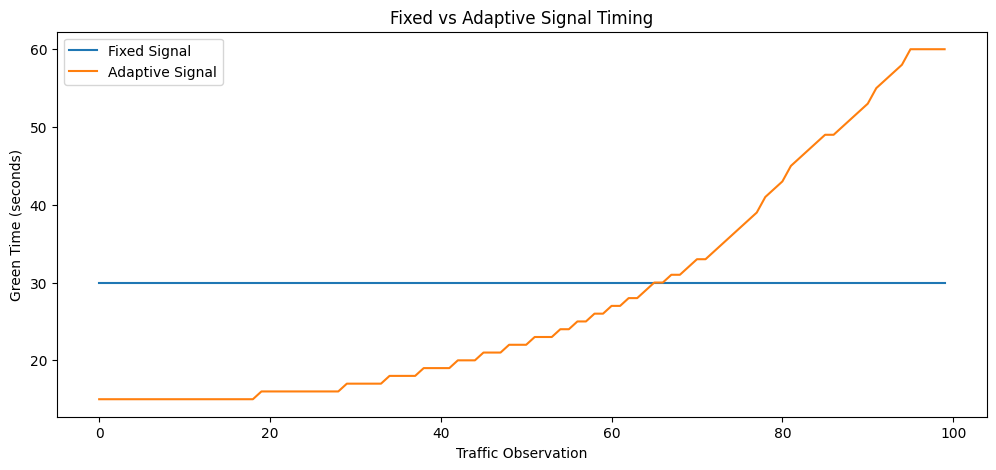

In [4]:
sample = (
    df.sort_values("traffic_pressure")
    .iloc[::max(len(df)//100, 1)]
    .head(100)
)

plt.figure(figsize=(12, 5))

plt.plot(
    range(len(sample)),
    sample["fixed_green"],
    label="Fixed Signal"
)

plt.plot(
    range(len(sample)),
    sample["reactive_green"],
    label="Adaptive Signal"
)

plt.xlabel("Traffic Observation")
plt.ylabel("Green Time (seconds)")
plt.title("Fixed vs Adaptive Signal Timing")
plt.legend()

plt.show()